## Завантаження даних

In [1]:
import pandas as pd

In [11]:
df_train = pd.read_csv("/Users/lilianamirchuk/Desktop/lpnu/8_семестр/mlops/mlops_lab_1/data/raw/train.csv")
df_test = pd.read_csv("/Users/lilianamirchuk/Desktop/lpnu/8_семестр/mlops/mlops_lab_1/data/raw/test.csv")
df_train


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


## Первинний аналіз даних (EDA)

### аналіз типів даних

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17197 entries, 0 to 17196
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      17197 non-null  int64 
 1   tweet   17197 non-null  object
dtypes: int64(1), object(1)
memory usage: 268.8+ KB


### перевірка наявності пропущених значень

In [5]:
df_train.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [6]:
df_test.isnull().sum()

id       0
tweet    0
dtype: int64

### Візуалізація розподілу цільової змінної

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/3b/zhltxyhs5732_rrcl6t6dyz40000gn/T/ipykernel_81700/1263879669.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_train, palette='viridis')


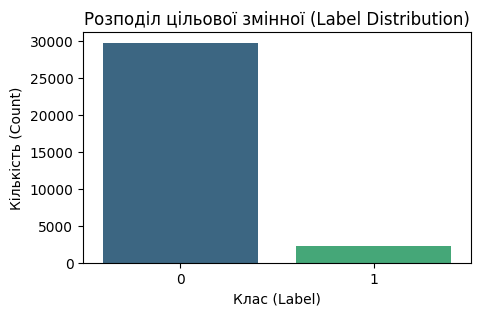

label
0    29720
1     2242
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(5, 3))
sns.countplot(x='label', data=df_train, palette='viridis')
plt.title('Розподіл цільової змінної (Label Distribution)')
plt.xlabel('Клас (Label)')
plt.ylabel('Кількість (Count)')
plt.show()

print(df_train['label'].value_counts())


### Побудова матриці кореляції (Correlation Matrix)

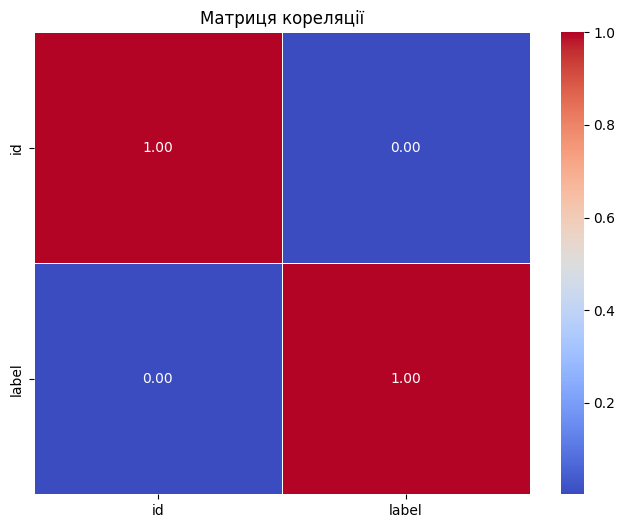

In [15]:
# Вибираю тільки числові колонки для матриці кореляції
numeric_cols = df_train.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

# Візуалізую матрицю кореляції за допомогою теплової карти (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляції')
plt.show()
